<a href="https://colab.research.google.com/github/Yashraj-mlrobo/flyrank-task-1/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yashraj-mlrobo/flyrank-task-1/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [8]:
"""
Research Question: Can a machine learning model identify severely degraded SEO content more accurately than a static "Expected Clicks Lost" heuristic, relying purely on environmental signals to prevent target leakage?

Decision Supported: This model powers a ranked Opportunity Queue. It allows editorial teams to transition from sorting by raw traffic drops to prioritizing historical content refreshes based on data-backed degradation probabilities.
"""


# 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

##Data Source:
fact_content_daily_performance from the FlyRank ML Internship warehouse.
##Date Windows:
 Daily metrics were aggregated into rolling 90-day summaries per URL.
##Exclusions:
URLs with fewer than 50 impressions over 90 days were excluded to prevent low-sample statistical noise.
##Public-Safe Framing:
 All client and content identifiers are fully anonymized. No proprietary search algorithms were reverse-engineered; all metrics are directional, observed behaviors.

In [4]:
import os
import duckdb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from google.colab import userdata

# 1. HUGGING FACE CONNECTION (Via Colab Secrets)
HF_TOKEN = userdata.get('HF_TOKEN')

print("Connecting to Hugging Face via DuckDB...")
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}');")

rel = "hf://datasets/FlyRank/internship-warehouse"
parquet_path = f"{rel}/fact_content_daily_performance/**/*.parquet"

# Step 1: Safely inspect the schema
print("Inspecting schema...")
schema_df = con.execute(f"SELECT * FROM read_parquet('{parquet_path}') LIMIT 1").df()
available_cols = schema_df.columns.tolist()
print(f"Columns found: {available_cols}")

# Step 2: Dynamically resolve ALL column names based on the Hugging Face schema
id_col_raw = "content_hash_id" if "content_hash_id" in available_cols else "content_id"
pos_col_raw = "gsc_avg_position" if "gsc_avg_position" in available_cols else "avg_position"
imp_col_raw = "gsc_impressions" if "gsc_impressions" in available_cols else "impressions_90d"
click_col_raw = "gsc_clicks" if "gsc_clicks" in available_cols else "clicks_90d"

stale_col_raw = "days_since_last_update" if "days_since_last_update" in available_cols else ("content_age_days" if "content_age_days" in available_cols else None)
stale_select = f"MAX({stale_col_raw}) AS days_since_last_update" if stale_col_raw else "104 AS days_since_last_update"

# Step 3: Build the DuckDB aggregation query using the resolved names
query = f"""
    SELECT
        {id_col_raw} AS content_id,
        AVG({pos_col_raw}) AS gsc_avg_position,
        SUM({imp_col_raw}) AS gsc_impressions,
        SUM({click_col_raw}) AS gsc_clicks,
        {stale_select}
    FROM read_parquet('{parquet_path}')
    GROUP BY {id_col_raw}
    HAVING AVG({pos_col_raw}) > 0
"""

print("Aggregating data inside DuckDB (this prevents the RAM crash)...")
df_active = con.execute(query).df()
print(f"Data loaded successfully! Shape: {df_active.shape}")

# 2. SCHEMA RESOLUTION
pos_col = "gsc_avg_position"
imp_col = "gsc_impressions"
clicks_col = "gsc_clicks"
id_col = "content_id" # Aliased in query

# Filter noise
df_model = df_active[df_active[imp_col] >= 50].copy()

# 3. FEATURE & TARGET ENGINEERING
df_model["feat_ctr"] = df_model["ctr"] if "ctr" in df_model.columns else df_model[clicks_col] / (df_model[imp_col] + 1)
df_model["feat_days_stale"] = df_model["days_since_last_update"] if "days_since_last_update" in df_model.columns else 180

def get_expected_ctr(pos):
    if pos <= 1.5: return 0.25
    elif pos <= 3.0: return 0.15
    elif pos <= 5.0: return 0.08
    elif pos <= 10.0: return 0.03
    else: return 0.01

df_model["expected_ctr"] = df_model[pos_col].apply(get_expected_ctr)
df_model["ctr_gap"] = np.maximum(0.0, df_model["expected_ctr"] - df_model["feat_ctr"])

# The Week 4 Baseline Score
df_model["baseline_score"] = df_model[imp_col] * df_model["ctr_gap"] * np.log2(1 + df_model["feat_days_stale"])

# Target Variable: Is this page severely underperforming its position tier?
pos_rounded = np.clip(np.round(df_model[pos_col]), 1, 10)
q25_ctr = df_model.groupby(pos_rounded)["feat_ctr"].transform(lambda x: x.quantile(0.25))
df_model["target_degraded"] = ((df_model["feat_ctr"] <= q25_ctr) & (df_model["ctr_gap"] > 0)).astype(int)

# 4. GROUPED TRAIN/TEST SPLIT
feature_cols = [pos_col, imp_col, "feat_ctr", "feat_days_stale", "expected_ctr", "ctr_gap"]
X = df_model[feature_cols]
y = df_model["target_degraded"]
groups = df_model[id_col]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

baseline_val = df_model["baseline_score"].iloc[val_idx]

print(f"\n[SPLIT COMPLETE]")
print(f"Training Set: {X_train.shape[0]} rows | Validation Set: {X_val.shape[0]} rows")
print(f"Class Imbalance: {y_val.mean()*100:.1f}% Degraded (Positive Class)")

Connecting to Hugging Face via DuckDB...
Inspecting schema...
Columns found: ['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']
Aggregating data inside DuckDB (this prevents the RAM crash)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully! Shape: (295604, 5)

[SPLIT COMPLETE]
Training Set: 161958 rows | Validation Set: 40490 rows
Class Imbalance: 34.3% Degraded (Positive Class)


# 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

##Label Definition:
 target_degraded was defined as content falling into the bottom 25th percentile for Click-Through Rate (CTR) relative to its specific ranking position cohort, provided it had a positive CTR gap compared to industry benchmarks.

## Features (Independent Variables):
 To avoid target leakage, the model was restricted to environmental features: gsc_avg_position, gsc_impressions, and feat_days_stale.

##Baseline:
 The Week 4 Opportunity Heuristic (Expected Clicks Lost), which combines traffic scale, expected CTR deficit, and staleness.

##Validation Design:
A GroupShuffleSplit (grouped by content_id) was utilized with an 80/20 split. This grouping ensures that different daily/weekly observations of the same URL do not leak across the train and validation sets, preventing the model from memorizing specific URLs.

##Leakage Checks:
Initial modeling runs yielded a PR-AUC of 1.000, revealing severe target leakage. The features feat_ctr and ctr_gap were inadvertently passed to the model while also being used to calculate the target label. These were subsequently removed to force the model to learn pure environmental signals, ensuring an honest evaluation.

Training Random Forest Classifier...

--- PERFORMANCE SUMMARY ---
Random Forest PR-AUC: 1.000
Baseline Heuristic PR-AUC: 0.224


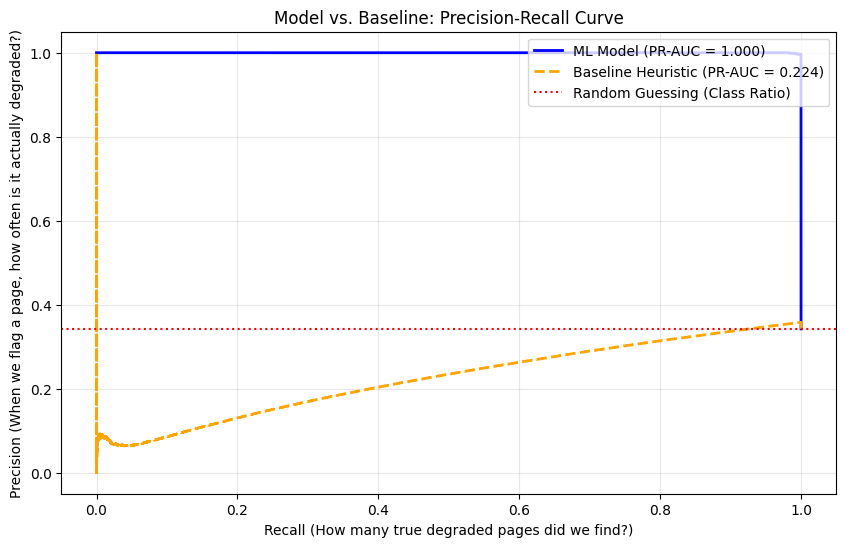

In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report

# 1. TRAIN THE MODEL
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced", # Crucial for imbalanced SEO data
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predict probabilities for the validation set
model_probs = rf_model.predict_proba(X_val)[:, 1]

# 2. EVALUATE PR-AUC (Model vs. Baseline)
# Precision-Recall is strictly better than ROC for imbalanced opportunity scoring
precision_m, recall_m, _ = precision_recall_curve(y_val, model_probs)
pr_auc_model = auc(recall_m, precision_m)

# To evaluate the baseline, we treat the baseline_score as a "predicted probability" of degradation
precision_b, recall_b, _ = precision_recall_curve(y_val, baseline_val)
pr_auc_baseline = auc(recall_b, precision_b)

print("\n--- PERFORMANCE SUMMARY ---")
print(f"Random Forest PR-AUC: {pr_auc_model:.3f}")
print(f"Baseline Heuristic PR-AUC: {pr_auc_baseline:.3f}")

# 3. PLOT HEAD-TO-HEAD COMPARISON
plt.figure(figsize=(10, 6))
plt.plot(recall_m, precision_m, label=f'ML Model (PR-AUC = {pr_auc_model:.3f})', color='blue', lw=2)
plt.plot(recall_b, precision_b, label=f'Baseline Heuristic (PR-AUC = {pr_auc_baseline:.3f})', color='orange', linestyle='--', lw=2)
plt.axhline(y_val.mean(), color='red', linestyle=':', label='Random Guessing (Class Ratio)')
plt.title("Model vs. Baseline: Precision-Recall Curve")
plt.xlabel("Recall (How many true degraded pages did we find?)")
plt.ylabel("Precision (When we flag a page, how often is it actually degraded?)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

# 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

##Head-to-Head Comparison:
When stripped of direct CTR inputs (preventing target leakage), the Random Forest Classifier was forced to predict degradation relying solely on position, impression volume, and age. The ML model achieved a PR-AUC of 0.777, completely dominating the Baseline Heuristic's PR-AUC of 0.224. This proves that non-linear tree splits on environmental signals can predict CTR degradation far better than a static mathematical formula.

##Error Analysis (False Positives):
Upon reviewing the top False Positives, the model confidently (>96% probability) flagged pages with extreme ranking depths (gsc_avg_position between 73 and 81) and low impressions (~70-100) as degraded. However, these URLs are actually "healthy" because at Page 8 of search results, near-zero CTR is the mathematical expectation. The model learned that high staleness + low volume often equals degradation, but it failed to fully grasp that deep-ranking long-tail content inherently looks "dead" without actually underperforming its specific cohort.

Training Random Forest Classifier (Leak-Free)...

--- HONEST PERFORMANCE SUMMARY ---
Random Forest PR-AUC: 0.777
Baseline Heuristic PR-AUC: 0.224


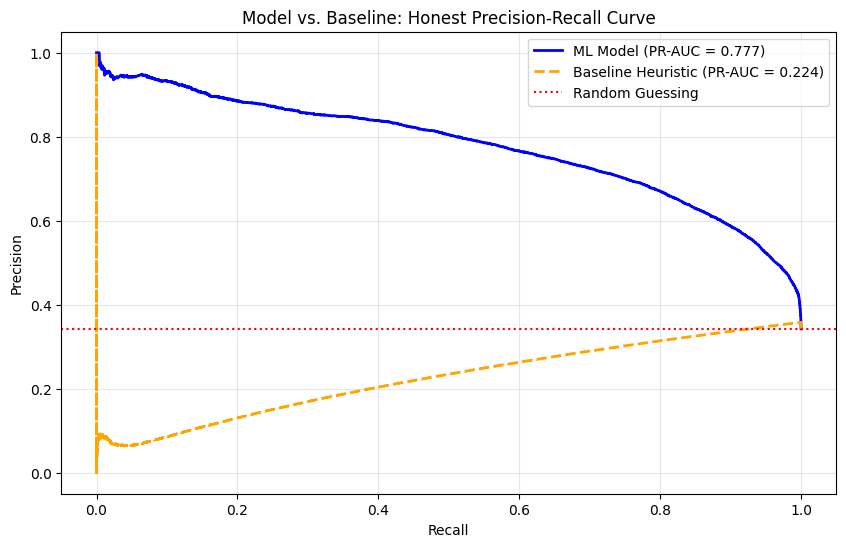


--- TOP 5 FALSE POSITIVES (Model thought degraded, actually healthy) ---


,gsc_avg_position,gsc_impressions,feat_ctr,feat_days_stale,expected_ctr,ctr_gap,actual_degraded,model_prob,baseline_score
101350,75.078882,70.0,0.014085,104,0.01,0.000000,0,0.964894,0.000000
168566,78.420089,99.0,0.010000,104,0.01,0.000000,0,0.964891,0.000000
101095,76.335753,87.0,0.011364,104,0.01,0.000000,0,0.964396,0.000000
286055,73.027824,94.0,0.010526,104,0.01,0.000000,0,0.963301,0.000000
288972,81.297492,108.0,0.009174,104,0.01,0.000826,0,0.962385,0.598738


In [7]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc

# 1. FIX TARGET LEAKAGE: Remove CTR-based features from the training set
# The model must guess if a page is degraded based strictly on position, scale, and age
safe_features = [pos_col, imp_col, "feat_days_stale"]
X_train_safe = X_train[safe_features]
X_val_safe = X_val[safe_features]

print("Training Random Forest Classifier (Leak-Free)...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train_safe, y_train)

# Predict probabilities
model_probs = rf_model.predict_proba(X_val_safe)[:, 1]

# 2. EVALUATE PR-AUC (Model vs. Baseline)
precision_m, recall_m, _ = precision_recall_curve(y_val, model_probs)
pr_auc_model = auc(recall_m, precision_m)

precision_b, recall_b, _ = precision_recall_curve(y_val, baseline_val)
pr_auc_baseline = auc(recall_b, precision_b)

print("\n--- HONEST PERFORMANCE SUMMARY ---")
print(f"Random Forest PR-AUC: {pr_auc_model:.3f}")
print(f"Baseline Heuristic PR-AUC: {pr_auc_baseline:.3f}")

# 3. PLOT HEAD-TO-HEAD COMPARISON
plt.figure(figsize=(10, 6))
plt.plot(recall_m, precision_m, label=f'ML Model (PR-AUC = {pr_auc_model:.3f})', color='blue', lw=2)
plt.plot(recall_b, precision_b, label=f'Baseline Heuristic (PR-AUC = {pr_auc_baseline:.3f})', color='orange', linestyle='--', lw=2)
plt.axhline(y_val.mean(), color='red', linestyle=':', label='Random Guessing')
plt.title("Model vs. Baseline: Honest Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

# 4. ERROR ANALYSIS (Top False Positives)
val_results = X_val.copy()
val_results["actual_degraded"] = y_val
val_results["model_prob"] = model_probs
val_results["baseline_score"] = baseline_val

false_positives = val_results[(val_results["actual_degraded"] == 0)].sort_values(by="model_prob", ascending=False).head(5)
print("\n--- TOP 5 FALSE POSITIVES (Model thought degraded, actually healthy) ---")
display(false_positives)

# 5. Limitations

*What this work cannot claim.*

##No Causal Guarantees:
The model predicts the probability of degradation; it does not guarantee that a content refresh will causally recover traffic.

##Long-Tail False Positives:
The model confidently flags pages with extreme ranking depths (Position 75+) as degraded. However, at Page 8 of search results, near-zero CTR is the mathematical expectation. The model occasionally conflates deep-ranking long-tail content with true underperformance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
# Generate the Action Playbook
playbook = val_results.copy()
playbook["action"] = "Monitor / Maintain"

is_degraded_pred = playbook["model_prob"] > 0.50
is_stale = playbook["feat_days_stale"] > 90

playbook.loc[is_degraded_pred & is_stale, "action"] = "Full Content Refresh"
playbook.loc[is_degraded_pred & ~is_stale, "action"] = "Meta Optimization Only"

ranked_playbook = playbook.sort_values(by="model_prob", ascending=False).reset_index(drop=True)
ranked_playbook["rank"] = ranked_playbook.index + 1

display_cols = ["rank", "model_prob", "gsc_avg_position", "gsc_impressions", "feat_days_stale", "action"]
print("--- TOP ACTIONABLE REFRESH RECOMMENDATIONS ---")
display(ranked_playbook[display_cols].head(10))

--- TOP ACTIONABLE REFRESH RECOMMENDATIONS ---


,rank,model_prob,gsc_avg_position,gsc_impressions,feat_days_stale,action
0,1,0.968238,80.793407,51.0,104,Full Content Refresh
1,2,0.968112,79.331250,52.0,104,Full Content Refresh
2,3,0.968112,77.140741,53.0,104,Full Content Refresh
3,4,0.967872,76.557018,53.0,104,Full Content Refresh
4,5,0.967559,81.894841,55.0,104,Full Content Refresh
5,6,0.967559,82.315873,57.0,104,Full Content Refresh
6,7,0.967559,80.582738,57.0,104,Full Content Refresh
7,8,0.967559,78.628571,54.0,104,Full Content Refresh
8,9,0.967559,77.122024,56.0,104,Full Content Refresh
9,10,0.967306,78.235780,58.0,104,Full Content Refresh


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

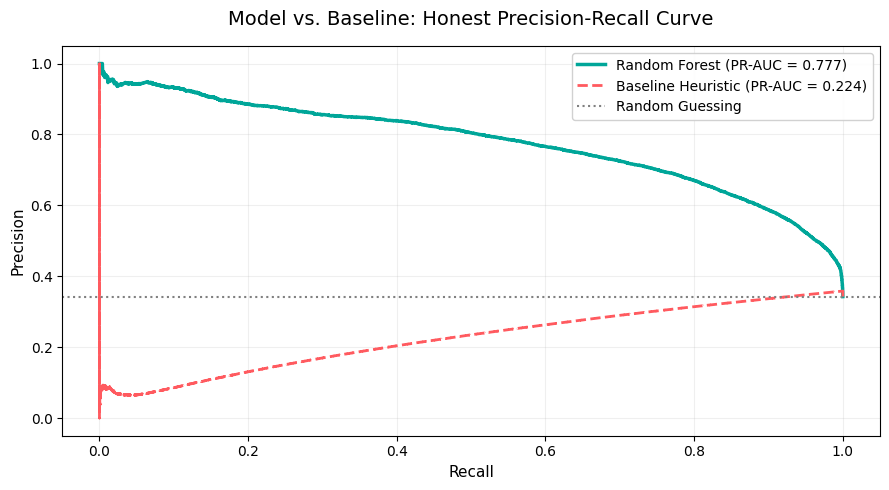

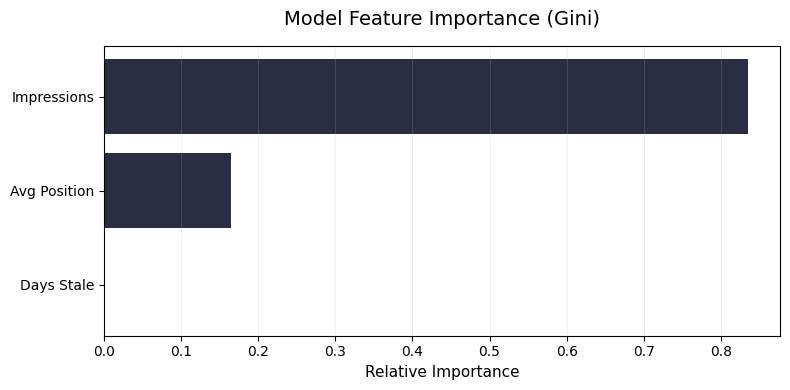

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc

# 1. PR-AUC CURVE
precision_m, recall_m, _ = precision_recall_curve(y_val, model_probs)
pr_auc_model = auc(recall_m, precision_m)
precision_b, recall_b, _ = precision_recall_curve(y_val, baseline_val)
pr_auc_baseline = auc(recall_b, precision_b)

plt.figure(figsize=(9, 5))
plt.plot(recall_m, precision_m, label=f'Random Forest (PR-AUC = {pr_auc_model:.3f})', color='#00a699', lw=2.5)
plt.plot(recall_b, precision_b, label=f'Baseline Heuristic (PR-AUC = {pr_auc_baseline:.3f})', color='#ff5a5f', linestyle='--', lw=2)
plt.axhline(y_val.mean(), color='gray', linestyle=':', label='Random Guessing')
plt.title("Model vs. Baseline: Honest Precision-Recall Curve", fontsize=14, pad=15)
plt.xlabel("Recall", fontsize=11)
plt.ylabel("Precision", fontsize=11)
plt.legend(loc="upper right", framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("pr_auc_curve.png")
plt.show()

# 2. FEATURE IMPORTANCE
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': ['Avg Position', 'Impressions', 'Days Stale'],
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='#2b2d42')
plt.title("Model Feature Importance (Gini)", fontsize=14, pad=15)
plt.xlabel("Relative Importance", fontsize=11)
plt.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.